In [1]:
pip install diffrax


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks")

import time
import jax
jax.config.update("jax_enable_x64", False)
import jax.numpy as jnp
import jax.random as jr
from jax import vmap, jit, value_and_grad
from dataclasses import dataclass
import equinox as eqx
import optax
import numpy as np
from typing import Tuple
from diffrax import diffeqsolve, Euler, Heun, SaveAt, ODETerm
from functools import partial

key = jr.PRNGKey(0)

# Example - A dynamical system with multiple observed trajectories

We will be doing system identification, given multiple observed trajectories from the excitation of deterministic Duffing Oscillator systems. As a reminder, the Duffing Oscillator is governed by the following equations of motion:


$$
\begin{align*}
   \dot{x} &= v \\
   \dot{v} &= -2\xi\omega_n v - \omega_n^2 x - \beta x^3 + \gamma \sin(\omega t). \\
   \\
   x(0) &= x_0, \\
   v(0) &= v_0.
\end{align*}
$$

where $x$ denotes the position and $v$ is the velocity, with initial conditions $x_0$ and $v_0$. The parameter $\xi$ is the damping ratio, $\omega_n$ is the natural frequency, and $\beta$ is the nonlinear stiffness coefficient. The system is driven by a known external forcing term $\gamma \sin(\omega t)$. Our observation $y$ from the system is acceleration measurements, which are corrupted by additive Gaussian noise with known variance.

The behavior of such a deterministic system is predictable by knowing the initial conditions and parameters. Accordingly, our goal is to infer the parameters $\mathbf{\theta} = (x_0, v_0, \omega_n, \xi, \beta)$ for the target system, given multiple observed trajectories from different systems in hand. To achieve this, we use amortized variational inference (AVI). AVI enables us to pay the expensive price of learning all inverse problems up front, by learning a global inference function; a map from data to the posterior distribution over the model parameters $\mathbf{\theta}$. Once trained offline, we can infer the parameters of a new target system really quickly.

Let's first write down the dynamics of the system:

In [3]:
# Duffing constants
class DuffingConsts(eqx.Module):
    gamma: float = eqx.field(static=True)
    omega: float = eqx.field(static=True)

# Vector field
def vector_field(t, y, args):
    """Duffing oscillator dynamics.

    Args:
        t: Current time
        y: State [x, v]
        args: (theta, gamma, omega) where theta = [x0, v0, wn, xi, beta]
    """
    theta, gamma, omega = args
    _, _, wn, xi, beta = theta[:5]

    # Compute control input
    u = gamma * jnp.sin(omega * t)

    x, v = y[0], y[1]
    return jnp.array([
        v,
        -2*xi*wn*v - wn**2*x - beta*x**3 + u
    ])

# ODE solver
solver = Heun() # more accurate and stable than Euler()
term = ODETerm(vector_field)
@jit
def solve_ode(theta: jnp.ndarray, ts: jnp.ndarray, consts) -> jnp.ndarray:
    """Solve Duffing ODE with given parameters and control input.

    Args:
        theta: Parameters [x0, v0, wn, xi, beta]
        ts: Time points
        consts: Excitation input constants, including gamma & omega

    Returns:
        xs: States (position and velocity) at time points
    """
    gamma = consts.gamma
    omega = consts.omega
    x0, v0 = theta[0], theta[1]
    saveat = SaveAt(ts=ts)

    sol = diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=jnp.array([x0, v0]),
        args=(theta, gamma, omega),
        saveat=saveat,
    )
    return sol.ys

# Observation function
def observation_duffing(theta: jnp.ndarray, xs: jnp.ndarray) -> jnp.ndarray:
    """Compute observation (acceleration) from states.

    Args:
        theta: Parameters [x0, v0, wn, xi, beta]
        xs: States position and velocity

    Returns:
        acs: Accelerations
    """
    _, _, wn, xi, beta = theta[:5]
    acs = -2 * xi * wn * xs[:, 1] - wn ** 2 * xs[:, 0] - beta * xs[:, 0] ** 3
    return acs


### Problem Constants and Target System
To keep things simple, we are simulating all our batches with evenly spaced measurements over a fixed 15-second window, all using the same sinusoidal input as the excitation. Here are the global settings we will use.

In [4]:
# Time parameters
t0 = 0.0
t1 = 15.0
dt = 0.04
ts = jnp.arange(t0, t1 + dt, dt)
t_len = len(ts)

# Control input constants
consts = DuffingConsts(gamma=0.8, omega=1.25)

# Observation noise parameter
sigma_meas = 1.0

# System parameters
list_theta = ['x0', 'v0', 'wn', 'xi', 'beta']
n_params = len(list_theta)


Let's look at the system we are trying to do the inference on. We will use the parameters below.

In [5]:
# Generate target trajectory
actual_theta = jnp.array([0.5, 0.1, 3.0, 0.2, 0.0])
print(
    f"True parameters: "
    f"x0={actual_theta[0]:.2f}, "
    f"v0={actual_theta[1]:.2f}, "
    f"wn={actual_theta[2]:.2f}, "
    f"xi={actual_theta[3]:.2f}, "
    f"beta={actual_theta[4]:.2f}"
)

# Solve ODE
target_xs = solve_ode(actual_theta, ts, consts)

# Compute noisy acceleration
target_obs = observation_duffing(actual_theta, target_xs)
target_obs = target_obs + jr.normal(key, target_obs.shape) * sigma_meas


True parameters: x0=0.50, v0=0.10, wn=3.00, xi=0.20, beta=0.00


Here is what the target system's trajectory looks like.

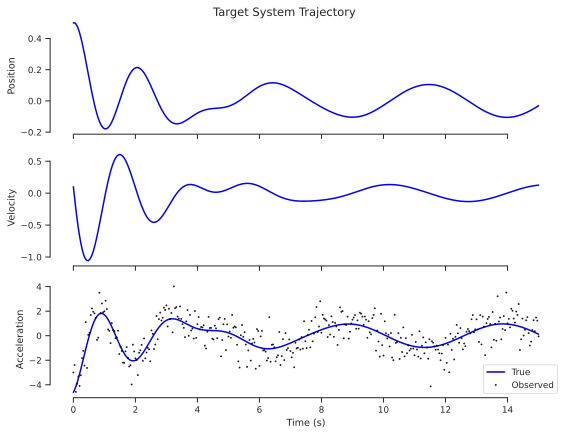

In [6]:
# Visualize target system
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

axes[0].plot(ts, target_xs[:, 0], 'b-', linewidth=1.5)
axes[0].set_ylabel('Position')

axes[1].plot(ts, target_xs[:, 1], 'b-', linewidth=1.5)
axes[1].set_ylabel('Velocity')

acs_true = observation_duffing(actual_theta, target_xs)
axes[2].plot(ts, acs_true, 'b-', linewidth=1.5, label='True')
axes[2].plot(ts, target_obs, 'ko', markersize=1, alpha=0.8, label='Observed')
axes[2].set_ylabel('Acceleration')
axes[2].set_xlabel('Time (s)')
axes[2].legend()

plt.tight_layout()
plt.suptitle('Target System Trajectory', y=1.00)
for ax in axes:
    sns.despine(ax=ax, trim=True)


You can see the observations from the system is pretty noisy!

## Formulation of the Problem

### Prior Definition

To set up our inference, we define priors for our parameters $\theta$ based on a fair state of knowledge about the system, and considering LogNormal distribution for $\omega_n$ and damping ratio $\xi$ to ensure positivity:

$$
\begin{aligned}
x_0 &\sim \mathcal{N}(0, 1), \\
v_0 &\sim \mathcal{N}(0, 1), \\
\beta &\sim \mathcal{N}(0, 0.5^2), \\
\omega_n &\sim \text{LogNormal}(1.2, 0.3^2), \\
\xi &\sim \text{LogNormal}(-1.9, 0.6^2).
\end{aligned}
$$

Let's define a prior class which is able to handle both distributions.

In [7]:
def normal_logpdf(x, mu, sigma):
    """Compute log N(x | mu, sigma^2) elementwise."""
    sigma_safe = jnp.maximum(sigma, 1e-6)
    z = (x - mu) / sigma_safe
    return -0.5 * z**2 - jnp.log(sigma_safe) - 0.5 * jnp.log(2.0 * jnp.pi)


@jax.tree_util.register_pytree_node_class
@dataclass(frozen=True)
class PriorSpec:
    """
    Prior specification for model parameters using unconstrained variables z.

    type_code:
        0 -> Normal prior on theta (identity transform)
        1 -> LogNormal prior on theta (z = log theta)
    """
    type_code: Tuple[int, ...]
    mu: jnp.ndarray
    sigma: jnp.ndarray

    def tree_flatten(self):
        """Tell JAX how to flatten this object into arrays for JIT/Vmap."""
        children = (self.mu, self.sigma)
        aux_data = self.type_code
        return children, aux_data

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        """Reconstruct object after JAX transformations."""
        mu, sigma = children
        return cls(type_code=aux_data, mu=mu, sigma=sigma)

    @property
    def is_lognormal(self):
        """Boolean mask indicating which parameters use LogNormal priors."""
        return jnp.array(self.type_code, dtype=jnp.int32) == 1

    def log_prior_z(self, z_unconstrained):
        """Prior in unconstrained space."""
        return normal_logpdf(z_unconstrained, self.mu, self.sigma)

    def log_prior_theta(self, theta_constrained):
        """Prior in constrained space."""
        theta = jnp.asarray(theta_constrained)

        # Normal on theta
        logp_normal = normal_logpdf(theta, self.mu, self.sigma)

        # LogNormal on theta: log(theta) ~ Normal(mu, sigma)
        is_pos = theta > 0
        log_theta = jnp.where(is_pos, jnp.log(theta), 0.0)

        logp_lognorm_valid = normal_logpdf(
            log_theta, self.mu, self.sigma) - log_theta
        logp_lognorm = jnp.where(is_pos, logp_lognorm_valid, -jnp.inf)
        return jnp.where(self.is_lognormal, logp_lognorm, logp_normal)

    def total_log_prior_z(self, z_unconstrained):
        """Compute the total log prior log p(z) summed over all parameters."""
        return jnp.sum(self.log_prior_z(z_unconstrained))

    def total_log_prior_theta(self, theta_constrained):
        """Compute total log p(theta) summed over parameters."""
        return jnp.sum(self.log_prior_theta(theta_constrained))

    def sample_theta(self, key, n_samples: int):
        """Draw samples from the prior in constrained parameter space."""
        eps = jr.normal(key, (n_samples, self.mu.shape[0]))
        z_samples = self.mu[None, :] + self.sigma[None, :] * eps
        return jnp.where(self.is_lognormal[None, :],
                        jnp.exp(z_samples),
                        z_samples)

@partial(jit, static_argnames=["n_samples"])
def sample_theta_from_prior(prior: PriorSpec, key, n_samples: int):
    """Sample parameters from the prior in constrained space."""
    return prior.sample_theta(key, n_samples)


In [ ]:
# Define prior on parameters
prior_types = (0, 0, 1, 1, 0) # 0 = Normal, 1 = LogNormal
prior_mus = jnp.array([0.0, 0.0, 1.2, -1.9, 0.0], dtype=jnp.float32)
prior_sigmas = jnp.array([1.0, 1.0, 0.3, 0.6, 0.5], dtype=jnp.float32)

prior = PriorSpec(type_code=prior_types, mu=prior_mus, sigma=prior_sigmas)


Let's check out some example trajectories using parameters sampled from our priors.
To keep things running smoothly (for both visualization and training) we filter out any trajectories that diverge, so we actually make about 30% more than ``n_trajectories`` than we need to ensure we have enough stable ones.
For the ODE part, we'll also work out a scaling factor, ``scale_obs``, which helps keep things numerically stable. This parameter will be used later when we scale our observations in training.

In [9]:
def generate_single_trajectory(key, prior, ts, consts):
    """Generate a single trajectory of the system.

    Uses the divergence checking for data generation.

    Args:
        key: JAX random key
        prior: Prior object
        ts: Time points
        consts: Excitation input constants, including amplitude and frequency

    Returns:
        obs: Noisy observations of acceleration
        is_valid: Boolean indicating whether the trajectory is non-divergent
    """
    # Sample model parameters from the prior (constrained space)
    key, theta_key, noise_key = jr.split(key, 3)
    theta = sample_theta_from_prior(prior, theta_key, 1)[0]

    # Solve the ODE to obtain state trajectory
    xs = solve_ode(theta, ts, consts)
    acs = observation_duffing(theta, xs)
    noise = jr.normal(noise_key, acs.shape) * sigma_meas
    obs = acs + noise

    # Check whether the trajectory diverged or numerically unstable
    is_div = is_divergent_trajectory(xs, obs)
    return xs, obs, ~is_div


@partial(jit, static_argnames=("minibatch_size",))
def generate_minibatch_trajectories(key, prior, ts, consts, minibatch_size):
    """Generate a minibatch of valid trajectories.

    Trajectories that diverge are discarded. Extra samples are
    generated to ensure that enough valid trajectories are collected.

    Args:
        key: JAX random key
        prior: Prior object
        ts: Time points
        consts: Excitation input constants, including amplitude and frequency
        minibatch_size: Number of valid trajectories to return

    Returns:
        obs_batch: Batch of observations
    """
    # Generate up to 1.3x to account for divergent cases
    buffer = int(minibatch_size * 1.3)

    # Generate trajectories
    keys = jr.split(key, buffer)
    _, obs_batch, valid_mask = vmap(
        lambda k, prior, ts, consts: generate_single_trajectory(
            k, prior, ts, consts),
        in_axes=(0, None, None, None),
    )(keys, prior, ts, consts)

    # Ensure at least one valid trajectory exists
    any_valid = jnp.any(valid_mask)
    fallback = jnp.where(any_valid, jnp.argmax(valid_mask), 0)

    # Select indices of valid trajectories
    idx = jnp.nonzero(valid_mask, size=minibatch_size, fill_value=fallback)[0]
    return obs_batch[idx]


@partial(jit,
    static_argnames=("threshold_pos", "threshold_vel", "threshold_acc"),)
def is_divergent_trajectory(
    xs, obs, threshold_pos=5.0, threshold_vel=10.0, threshold_acc=50.0):
    """
    Check whether a simulated trajectory is numerically unstable or divergent.

    Args:
        xs: State trajectory (position, velocity)
        obs: Observation trajectory
        threshold_pos: Maximum allowed absolute position
        threshold_vel: Maximum allowed absolute velocity
        threshold_acc: Maximum allowed absolute observation value

    Returns:
        is_divergent: Boolean indicating whether the trajectory is invalid
    """
    # Extract position and velocity
    pos = xs[:, 0]
    vel = xs[:, 1]

    # Compute maximum absolute values
    pos_max = jnp.max(jnp.abs(pos))
    vel_max = jnp.max(jnp.abs(vel))
    obs_max = jnp.max(jnp.abs(obs))

    # Check for NaNs or infinities
    xs_finite = jnp.all(jnp.isfinite(xs))
    obs_finite = jnp.all(jnp.isfinite(obs))

    return (
        (~xs_finite) | (~obs_finite)
        | ((pos_max > threshold_pos) | (vel_max > threshold_vel))
        | (obs_max > threshold_acc)
    )

Here we plot the trajectories.

In [10]:
# Generate trajectories from prior
key, subkey = jr.split(key)
n_trajectories = 50
n_trajectories_buffer = int(n_trajectories * 1.3)

# Sample trajectories
key_traj = jr.split(subkey, n_trajectories_buffer)
results = vmap(generate_single_trajectory,
               in_axes=(0, None, None, None))(key_traj, prior, ts, consts)
xs_batch, obs_batch, valid_mask = results

# Get valid trajectories
valid_indices = jnp.where(valid_mask)[0][:n_trajectories]
xs_valid =  xs_batch[valid_indices]
obs_valid = obs_batch[valid_indices]
scale_obs = float(jax.device_get(obs_valid.std()))

# Plot trajectories
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
for i in range(n_trajectories):
    axes[0].plot(ts, xs_valid[i, :, 0], 'b-', alpha=0.3, linewidth=0.5)
    axes[1].plot(ts, xs_valid[i, :, 1], 'b-', alpha=0.3, linewidth=0.5)
    axes[2].plot(ts, obs_valid[i], 'b.', alpha=0.2, markersize=0.5)

axes[0].set_ylabel('Position')
axes[1].set_ylabel('Velocity')
axes[2].set_ylabel('Acceleration')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.suptitle('Sample Trajectories from Prior', y=1.00)
for ax in axes:
    sns.despine(ax=ax, trim=True)


Nice! The specified prior gives us a fair general insight about the system behavior, and it is not too limiting.

### Guide Setup

For our guide $q(\theta)$, we use a [multivariate Gaussian posterior with full covariance](https://predictivesciencelab.github.io/advanced-scientific-machine-learning/inverse/vi/01_basics.html#guide-example-3-gaussian-with-full-covariance). To make the Gaussian approximation appropriate, we have to also consider a transformation $z = T(\theta)$ to convert our physical constraint space $\theta$ to unconstrained Gaussian guide $z$.

$$
q_{\phi}(\theta)
= \tilde{q}_{\phi}\!\big(T(\theta)\big)\,\left|\det J_T(\theta)\right|
= \mathcal{N}\!\big(T(\theta)\mid \mu_{\phi},\, L_{\phi}L_{\phi}^{\mathsf T}\big)\,
\left|\det J_T(\theta)\right|.
$$

where $L_{\phi}$ is lower triangular (Cholesky decomposition), parameterized by ${\phi}$, and
$J_T(\theta) = \frac{\partial z}{\partial \theta}$ denotes the Jacobian of the transformation
from the constrained parameter space to the unconstrained space.

In [11]:
class FullRankGaussianGuide(eqx.Module):
    """Multivariate normal guide with variational parameters phi."""
    guide_params: jnp.ndarray
    num_model_params: int = eqx.field(static=True, default=None)

    def __post_init__(self):
        expected = self.get_num_guide_params(self.num_model_params)
        if self.guide_params.shape[0] != expected:
            raise ValueError(
                "The length of phi is not consistent with number of parameters."
            )

    def logprob(self, model_params):
        """The log probability density of the guide."""
        return jax.scipy.stats.multivariate_normal.logpdf(
            model_params, self.mu, self.Sigma
        )

    def sample(self, key, num_samples):
        """Samples from the guide."""
        return jr.multivariate_normal(
            key, self.mu, self.Sigma, shape=(num_samples,)
        )

    def forward(self, epsilon):
        """Reparameterization trick: transform N(0,I) sample to guide sample."""
        return self.mu + jnp.dot(self.L, epsilon)

    @property
    def mu(self):
        """The mean of the guide."""
        return self.guide_params[: self.num_model_params]

    @property
    def Sigma(self):
        """The covariance of the guide."""
        L = self.L
        return jnp.dot(L, L.T)

    @property
    def L(self):
        """The Cholesky factor of the covariance of the guide."""
        n = self.num_model_params

        # Diagonal (positive via exp)
        ell = jnp.exp(self.guide_params[n : 2 * n])
        L = jnp.diag(ell)

        # Strictly lower-triangular entries
        tril_idx = jnp.tril_indices(n, -1)
        L = L.at[tril_idx].set(self.guide_params[2 * n :])
        return L

    @classmethod
    def from_mean_covariance(cls, mu, Sigma):
        """Initialize guide_params from a given mean and covariance."""
        L = jnp.linalg.cholesky(Sigma)
        ell = jnp.diag(L)
        tri = L[jnp.tril_indices(L.shape[0], -1)]
        guide_params = jnp.hstack([mu, jnp.log(ell), tri])
        return cls(guide_params=guide_params, num_model_params=mu.shape[0])

    @staticmethod
    def get_num_guide_params(num_model_params):
        """Return the number of guide parameters."""
        num_mu_params = num_model_params
        num_L_params = num_model_params * (num_model_params + 1) // 2
        return num_mu_params + num_L_params


In [12]:
# Guide Transform: z (unconstrained) <-> theta (constrained)
@jax.tree_util.register_pytree_node_class
@dataclass(frozen=True)
class ConstraintTransform:
    """
    Constraint transform used by the guide:
      z ∈ R^d  -->  theta in constrained space

    type_code per-dimension:
      0 -> identity: theta = z
      1 -> exp:      theta = exp(z)   (positive constraint)
    """
    type_code: Tuple[int, ...]

    def tree_flatten(self):
        children = ()
        aux_data = self.type_code
        return children, aux_data

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        del children
        return cls(type_code=aux_data)

    @property
    def is_exp(self):
        return jnp.array(self.type_code, dtype=jnp.int32) == 1

    def forward(self, z):
        """z -> theta"""
        return jnp.where(self.is_exp, jnp.exp(z), z)

    def inverse(self, theta):
        """theta -> z"""
        theta_pos = jnp.maximum(theta, jnp.finfo(theta.dtype).tiny)
        return jnp.where(self.is_exp, jnp.log(theta_pos), theta)

    def log_abs_det_jacobian(self, z):
        """log |det(d theta / d z)| elementwise for z -> theta"""
        # identity: 0, exp: log|exp(z)| = z
        return jnp.where(self.is_exp, z, 0.0)

    def total_log_abs_det_jacobian(self, z):
        return jnp.sum(self.log_abs_det_jacobian(z))


# Helper for transforming between constrained and unconstrained spaces
@jit
def z_to_theta(constraint: ConstraintTransform, z):
    """Transform parameters to constrained space."""
    return constraint.forward(z)

@jit
def theta_to_z(constraint: ConstraintTransform, theta):
    """Transform parameters to unconstrained space."""
    return constraint.inverse(theta)

@jit
def total_logdet_z_to_theta(constraint: ConstraintTransform, z):
    """Compute total log |det(d theta/d z)| summed over parameters."""
    return constraint.total_log_abs_det_jacobian(z)


In [13]:
# Define constraint transform on guide parameters (parameterization)
constraint = ConstraintTransform(type_code=prior_types)

### ELBO Definition

Quick reminder that in variational inference (VI), we want to maximize the Evidence Lower Bound (ELBO) with respect to $\phi$, which is $\max_{\phi} \mathrm{ELBO}(\phi)$.

$$\mathrm{ELBO}(\phi)
=
\mathbb{E}_{q_{\phi}(\theta)}
\big[
\log p(\mathbf{y}\mid \theta)
+ \log p(\theta)
- \log q_{\phi}(\theta)
\big].$$

Below we code the computation of ELBO for our problem. ELBO combines three parts:
- $p(\theta)$: the prior over system parameters ($\theta$)
- $p(\mathbf{y} \mid \theta)$: the likelihood of the observed system trajectory ($\mathbf{y}$)
- $q_{\phi}(\theta)$: the variational guide distribution, whose entropy discourages collapse to a point estimate

To compute the likelihood term, we draw ``n_mc_samples`` parameter samples from the guide (using the reparameterization trick), solve the ODE for each parameter set, and compare the resulting trajectories to the observed data vector $\mathbf{y}$.

In [14]:
@jit
def log_likelihood(obs, ts, consts, theta, sigma_meas):
    """Compute log likelihood under Gaussian measurement noise."""
    # Solve ODE
    xs = solve_ode(theta, ts, consts)
    acc_pred = observation_duffing(theta, xs)

    # Log likelihood
    residuals = obs - acc_pred
    n = obs.shape[0]

    sigma2 = sigma_meas**2
    log_norm = -0.5 * n * jnp.log(2.0 * jnp.pi * sigma2)
    quad = -0.5 * jnp.sum(residuals**2) / sigma2
    return log_norm + quad

def elbo_single_sample(prior, constraint, obs, ts, consts,
                       z_sample, guide, sigma_meas):
    """ELBO computation for a single MC sample.

    Args:
        prior: Prior object
        constraint: Constraint transform
        obs: Observations over time
        ts: Time grid
        consts: Excitation input constants, including amplitude and frequency
        z_sample: One parameter sample in unconstrained space
        guide: FullRankGaussianGuide instance
        sigma_meas: Measurement noise std

    Returns:
        elbo_val: scalar ELBO value
    """
    # Transform to constrained space
    theta_sample = constraint.forward(z_sample)

    # Log prior
    log_prior = prior.total_log_prior_theta(theta_sample)

    # Log likelihood
    log_lik = log_likelihood(obs, ts, consts, theta_sample, sigma_meas)

    # Log variational posterior using guide
    log_q_val = guide.logprob(z_sample)

    # Log det jacobian
    log_det_jac = constraint.total_log_abs_det_jacobian(z_sample)

    # ELBO term
    elbo_val = log_prior + log_lik - log_q_val + log_det_jac
    return elbo_val


@partial(jit, static_argnames=['n_params'])
def elbo_batch_reparameterized(prior, constraint, obs, ts, consts,
                                          guide_params, sigma_meas,
                                          epsilon_batch, n_params=5):
    """Compute mean ELBO over MC samples using reparameterization.

    Args:
        prior: Prior object
        constraint: Constraint transform
        obs: Observations over time
        ts: Time grid
        consts: Excitation input constants, including amplitude and frequency
        guide_params: Packed parameters for FullRankGaussianGuide.
        sigma_meas: Measurement noise std
        epsilon_batch: Standard normal samples
        n_params: Number of parameters

    Returns:
        mean ELBO over MC samples
    """
    # Create guide from parameters
    guide = FullRankGaussianGuide(guide_params, n_params)

    # Reparameterization
    z_samples = vmap(guide.forward)(epsilon_batch)

    # Compute ELBO for each sample
    def compute_single_elbo(z_sample):
        return elbo_single_sample(
            prior, constraint, obs, ts, consts, z_sample, guide, sigma_meas
        )

    # Compute ELBO for all MC samples
    elbos = vmap(compute_single_elbo)(z_samples)

    # Filter and average
    finite_elbos = jnp.where(jnp.isfinite(elbos), elbos, -1e9)
    return jnp.mean(finite_elbos)

### Variational Inference (VI) Implementation

We would like to implement both standard variational inference (as a baseline) and amortized variational inference (as an online inference). The following code enables us to do that through specifying the ``mode`` of execution.

In [15]:
def run_vi(mode, key, obs, ts, consts, sigma_meas, prior, constraint,
           inference_model=None, minibatch_size=None, n_steps=1000,
           n_mc_samples=5, learning_rate=0.0001):
    """Run variational inference (in standard or amortized mode).

    Args:
        mode: "standard" or "amortized"
        key: Random key
        obs: Observations for standard VI (unused for amortized mode)
        ts: Time points
        consts: Excitation input constants, including amplitude and frequency
        sigma_meas: Measurement noise std
        prior: Prior class
        constraint: Constraint transform of the guide
        inference_model: NeuralNetworkEncoder (for amortized mode)
        minibatch_size: Batch size (for amortized mode)
        n_steps: Number of optimization steps
        n_mc_samples: Number of Monte Carlo samples for ELBO
        learning_rate: Learning rate

    Returns:
        For standard VI: (guide, elbo_history, total_time)
        For amortized VI: (trained_model, elbo_history, total_time)
    """
    # Time the process
    t_start = time.perf_counter()

    prior_mus = prior.mu
    prior_sigmas = prior.sigma
    n_params = prior_mus.shape[0]

    # Loss function for single trajectory
    @jit
    def single_trajectory_loss(guide_params_single, obs_single, epsilon):
        """Compute negative ELBO for a single trajectory.

        Args:
            guide_params_single: guide parameters
            obs_single: observations
            epsilon: standard normal samples
        """
        return -elbo_batch_reparameterized(
            prior, constraint, obs_single, ts, consts,
            guide_params_single, sigma_meas, epsilon, n_params)

    # Mode specific setup
    if mode == "standard":
        # Initialize guide from prior
        mean_init = prior_mus
        sigma_init = jnp.diag(prior_sigmas ** 2)
        guide = FullRankGaussianGuide.from_mean_covariance(mean_init, sigma_init)
        params = guide.guide_params  # Optimize guide params directly

        # Loss and gradient function
        def loss_fn(p, obs_data, epsilon_data):
            return single_trajectory_loss(p, obs_data, epsilon_data)
        loss_and_grad = jit(value_and_grad(loss_fn))

        # Data generator (always use same trajectory)
        def get_batch_data(k):
            k, subkey = jr.split(k)
            epsilon = jr.normal(subkey, shape=(n_mc_samples, n_params))
            return k, obs, epsilon

        # Final output constructor
        def get_result(p):
            return FullRankGaussianGuide(p, n_params)

    elif mode == "amortized":
        params = inference_model  # Optimize neural network

        # Batch loss function
        def loss_fn(model, obs_batch, epsilon_batch):
            """Compute mean loss over batch of trajectories.

            Args:
                model: NeuralNetworkEncoder
                obs_batch: observations
                epsilon_batch: standard normal samples
            """
            def process_single(obs, epsilon):
                mean, L_flat = model(obs)
                guide_params = jnp.concatenate([mean, L_flat])
                return single_trajectory_loss(guide_params, obs, epsilon)
            losses = vmap(process_single)(obs_batch, epsilon_batch)
            return jnp.mean(losses)

        loss_and_grad = eqx.filter_value_and_grad(loss_fn)

        # Data generator
        def get_batch_data(k):
            k, batch_key, eps_key = jr.split(k, 3)
            obs_batch = generate_minibatch_trajectories(
                batch_key, prior, ts, consts, minibatch_size)
            epsilon = jr.normal(eps_key,
                                shape=(minibatch_size, n_mc_samples, n_params))
            return k, obs_batch, epsilon

        # Final output
        def get_result(p):
            return p

    else:
        raise ValueError(f"Unknown mode: {mode}. Must be 'standard/amortized'")

    # Optimizer
    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.apply_if_finite(optax.adam(learning_rate=learning_rate), 100),)
    opt_state = optimizer.init(eqx.filter(params, eqx.is_array))

    # Optimization loop
    elbo_history = []
    for step in range(n_steps):
        # Get batch data
        key, obs_data, epsilon_data = get_batch_data(key)

        # Calculate loss and gradient
        loss_val, grads = loss_and_grad(params, obs_data, epsilon_data)

        # Update parameters
        updates, opt_state = optimizer.update(grads, opt_state)
        params = eqx.apply_updates(params, updates)

        # Store ELBO
        current_elbo = float(-loss_val)
        elbo_history.append(current_elbo)
        if (step + 1) % 100 == 0:
            print(f"Step {step+1}/{n_steps}, ELBO: {current_elbo:.2e}")

    # Time the process
    jax.block_until_ready(params)
    total_time = time.perf_counter() - t_start
    # Return final result
    return get_result(params), elbo_history, total_time

### Run VI for Target System

As the baseline, we run the standard VI first. In standard variational inference, we do not have any pre-training step with previously observed trajectories of plausible behaviors. The whole optimization process is done given the observation trajectory of the system only.

In [16]:
# Run VI for target system
print("\n" + "="*50)
print("Running Standard VI")
print("="*50)

key, subkey = jr.split(key)
vi_guide, vi_elbo_history, vi_time = run_vi(
    mode = "standard",
    key = subkey,
    obs = target_obs,
    ts = ts,
    consts = consts,
    sigma_meas = sigma_meas,
    prior = prior,
    constraint = constraint,
    n_steps = 2000,
    n_mc_samples = 5,
    learning_rate = 1e-2,
)



Running Standard VI
Step 100/2000, ELBO: -5.71e+02
Step 200/2000, ELBO: -5.53e+02
Step 300/2000, ELBO: -5.39e+02
Step 400/2000, ELBO: -5.30e+02
Step 500/2000, ELBO: -5.30e+02
Step 600/2000, ELBO: -5.29e+02
Step 700/2000, ELBO: -5.28e+02
Step 800/2000, ELBO: -5.29e+02
Step 900/2000, ELBO: -5.29e+02
Step 1000/2000, ELBO: -5.30e+02
Step 1100/2000, ELBO: -5.29e+02
Step 1200/2000, ELBO: -5.29e+02
Step 1300/2000, ELBO: -5.29e+02
Step 1400/2000, ELBO: -5.28e+02
Step 1500/2000, ELBO: -5.29e+02
Step 1600/2000, ELBO: -5.28e+02
Step 1700/2000, ELBO: -5.29e+02
Step 1800/2000, ELBO: -5.28e+02
Step 1900/2000, ELBO: -5.28e+02
Step 2000/2000, ELBO: -5.28e+02


Let's take a look at the ELBO trend.

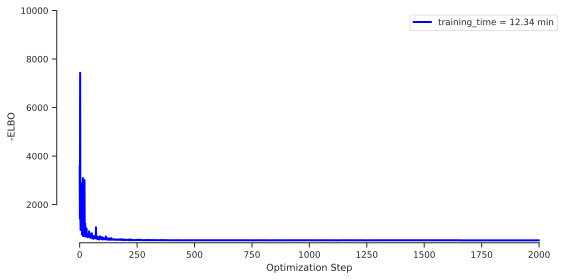

In [17]:
# Plot ELBO convergence
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(-np.array(vi_elbo_history), "b-",
        linewidth=2,
        label=f"training_time = {vi_time / 60:.2f} min")
ax.set_ylim(min(-np.array(vi_elbo_history))-100, 1e4)
# ax.set_yscale('log')
ax.set_xlabel('Optimization Step')
ax.set_ylabel('-ELBO')
plt.tight_layout()
ax.legend()
sns.despine(ax=ax, trim=True);


Looks good! The loss seems to be converging, though running for some more steps might have improved things further a bit. We will take a look at the predictive posteriors at the end of this notebook.

### Inference Function & Setup for Amortized VI

In Amortized VI (AVI), instead of tuning individual guide parameters for each dataset, we construct our guide conditional on the observational data $q_{\phi'}(\theta \mid \mathbf{y})$. We use an inference function (usually a neural network) to learn a global mapping from observations to guide parameters. This means we optimize the expected ELBO averaged over many trajectories sampled from the prior. Our loss to minimize would be the amortized ELBO (AELBO) which has as an outer expectation over the data too


$$\mathrm{AELBO}(\phi')
=
\mathbb{E}_{p(\mathbf{y})}
\Big[
\mathbb{E}_{q_{\phi'}(\theta \mid \mathbf{y})}
\big(
\log p(\mathbf{y}\mid \theta)
+ \log p(\theta)
- \log q_{\phi'}(\theta \mid \mathbf{y})
\big)
\Big].$$


Here, $p(\mathbf{y})$ is the data-generating process, $q_{\phi'}(\theta\,|\,\mathbf{y})$ is the inference (guide) network parameterized by $\phi'$, $p(\mathbf{y}\,|\,\theta)$ is the likelihood, and $p(\theta)$ is the prior. We learn the network parameters $\phi'$ by maximizing the expected ELBO over datasets $\mathbf{y}$ drawn from $p(\mathbf{y})$.

Below, we'll build neural networks (as the inference make) that take in our observed data and output the parameters (mean and covariance) for the posterior guide. Since we are using a full covariance matrix (via its Cholesky factor L), the number of covariance parameters is $n (n+1) / 2$, containing diagonal and off-diagonal terms.


In [18]:
# Inference function (with inductive bias)
class NeuralNetworkEncoder(eqx.Module):
    """
    Class that represents the inference map from the data to the parameters.
    Encodes a fixed-size input observational data into mean and cov outputs.
    """
    hidden: list[eqx.nn.Linear]
    mu_head: eqx.nn.MLP
    cov_head: eqx.nn.MLP

    priors_mu_theta: tuple[float, ...] = eqx.field(static=True)
    priors_sigma_theta: tuple[float, ...] = eqx.field(static=True)

    out_dim_mu: int = eqx.field(static=True)
    out_dim_cov: int = eqx.field(static=True)
    scales: float = eqx.field(static=True)


    def __init__(self, key, t_len, last_hidden_dim, out_dim_mu, out_dim_cov,
                 hidden_layers=2, branch_depth=2, scales=None,
                 priors_mu_theta=None, priors_sigma_theta=None):
        """
        Args:
            key: Random key
            t_len: Length of input sequence
            last_hidden_dim: Dimension of the final hidden layer (trunk output)
            out_dim_mu: Output dimension for mean
            out_dim_cov: Output dimension for covariance matrix
            hidden_layers: Number of hidden layers in trunk
            branch_depth: Depth of branch MLPs
            scales: Data standardization constant
            priors_mu_theta: Prior means for output bias
            priors_sigma_theta: Prior standard deviations for output bias
        """
        keys = jr.split(key, hidden_layers + 2)
        self.scales = scales
        self.out_dim_mu = out_dim_mu
        self.out_dim_cov = out_dim_cov

        self.priors_mu_theta = (
            priors_mu_theta if priors_mu_theta is not None
            else tuple([0.0] * out_dim_mu))
        self.priors_sigma_theta = (
            priors_sigma_theta if priors_sigma_theta is not None
            else tuple([1.0] * out_dim_mu))

        # Trunk
        self.hidden = []
        prev_dim = t_len
        for i in range(hidden_layers):
            # dimension of the next layer
            next_out_dim = int(
                t_len * (hidden_layers - i - 1) / hidden_layers +
                last_hidden_dim * (i + 1) / hidden_layers
            )

            # Append the layer
            self.hidden.append(
                eqx.nn.Linear(prev_dim, next_out_dim, key=keys[i]))

            # update the dimension for next layer
            prev_dim = next_out_dim


        # Vectorized heads for mean and covariance parameters
        self.mu_head = eqx.nn.MLP(
            last_hidden_dim,
            out_dim_mu,
            width_size=last_hidden_dim // 2,
            depth=branch_depth,
            activation=jax.nn.silu,
            key=keys[hidden_layers],
        )

        self.cov_head = eqx.nn.MLP(
            last_hidden_dim,
            out_dim_cov,
            width_size=last_hidden_dim // 2,
            depth=branch_depth,
            activation=jax.nn.silu,
            key=keys[hidden_layers + 1],
        )

    def __call__(self, x):
        """Process input through the neural network.

        Args:
            x: observations

        Returns:
            mean_output
            covariance_output
        """
        x = x.reshape(-1, 1)

        # Standardize data if scales provided
        if self.scales is not None:
            x = x / self.scales
        x = x.flatten()

        # Process through trunk and branches
        for layer in self.hidden:
            x = jax.nn.silu(layer(x))

        nn_mu = self.mu_head(x)
        nn_cov = self.cov_head(x)

        # Mean: prior mean as bias
        mean_output = jnp.asarray(self.priors_mu_theta) + nn_mu

        # Covariance: diagonal uses prior sigma, off-diagonal 0
        n_diag = len(self.priors_sigma_theta)
        n_off = self.out_dim_cov - n_diag

        cov_bias = jnp.concatenate(
            [jnp.log(jnp.asarray(self.priors_sigma_theta)), jnp.zeros(n_off)])
        cov_mult = jnp.concatenate([2.0*jnp.ones(n_diag), 0.01*jnp.ones(n_off)])
        covariance_output = cov_bias + cov_mult * nn_cov

        log_diag = covariance_output[:n_diag]
        off_diag = covariance_output[n_diag:]

        # Clip to avoid instability
        log_diag = jnp.clip(log_diag, jnp.log(1e-5), jnp.log(10.0))
        covariance_output = jnp.concatenate([log_diag, off_diag])

        return mean_output, covariance_output


Let's set up our inference neural net! We'll pick the layers and neurons, and bake in our prior right into the network architecture as an inductive bias. This will be the inference model we actually train on our data.

In [19]:
# Construct inference model with specific architecture
key, subkey = jr.split(key)
inference_model = NeuralNetworkEncoder(
    key = subkey,
    t_len = t_len,
    last_hidden_dim = 300,    # Final hidden dimension of trunk
    out_dim_mu = n_params,
    out_dim_cov = n_params * (n_params + 1) // 2,
    hidden_layers = 2,        # Number of trunk layers
    branch_depth = 2,         # Depth of branch MLPs
    scales = scale_obs,
    priors_mu_theta = tuple(prior_mus.tolist()),
    priors_sigma_theta = tuple(prior_sigmas.tolist()),
)


### AVI Training

Time to actually train our AVI! For each training step, we'll create a new batch of trajectories to learn from (that's what ``minibatch_size`` controls), in addition to running a bunch of forward ODE simulations (that's ``n_mc_samples``) for each. Just a heads up; this takes a decent amount of compute and isn't super fast! You’ll need to actually use the GPU in Google Colab; otherwise, the session will crash.

If we had unlimited compute, we'd run tons of training steps to explore and exploit every possible trajectory. But to keep things reasonable, we'll just do $1000$ steps for our training now.

In [ ]:
# Train AVI inference model
print("\n" + "="*50)
print("Training AVI Model")
print("="*50 )

key, subkey = jr.split(key)
avi_model_trained, avi_elbo_history, avi_training_time = run_vi(
    mode = "amortized",
    key = subkey,
    obs = None,
    ts = ts,
    consts = consts,
    sigma_meas = sigma_meas,
    prior = prior,
    constraint = constraint,
    inference_model = inference_model,
    minibatch_size = 5,
    n_steps = 1000,
    n_mc_samples = 6,
    learning_rate = 1e-4
)



Training AVI Model
Step 100/1000, ELBO: -1.21e+03
Step 200/1000, ELBO: -7.76e+02
Step 300/1000, ELBO: -6.75e+02
Step 400/1000, ELBO: -9.76e+02
Step 500/1000, ELBO: -8.70e+02
Step 600/1000, ELBO: -9.21e+02
Step 700/1000, ELBO: -1.17e+03
Step 800/1000, ELBO: -6.00e+02
Step 900/1000, ELBO: -1.50e+03
Step 1000/1000, ELBO: -7.53e+02


Let's take a look at how the ELBO evolves during the training of the inference function.

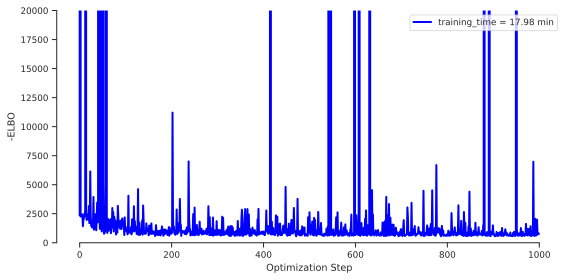

In [ ]:
# Visualize AVI training
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(-np.array(avi_elbo_history), "b-",
        linewidth=2,
        label=f"training_time = {avi_training_time / 60:.2f} min")
# plt.yscale('log')
ax.set_ylim(0, 2e4)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('-ELBO')
plt.tight_layout()
ax.legend()
sns.despine(ax=ax, trim=True);


Looking good! The high loss oscillations happen because each training step sees new, unique data. More data, more training, or a bigger inference model (e.g., deeper NN) could smooth things out even more, although this would require higher computational time. But this result looks solid for now.

### Run AVI for Target System

Let's put our trained AVI model to use! We can quickly get parameter estimates for a new (target) system with AVI. Here is how to run inference on new data with our trained AVI model:

In [22]:
# Run AVI Inference for target system
avi_mean, avi_L = avi_model_trained(target_obs)
avi_guide_params = jnp.concatenate([avi_mean, avi_L])
avi_guide = FullRankGaussianGuide(avi_guide_params, n_params)


We have now made predictions for our new observed data. Nice! It only took a moment to infer the posterior, pretty fast!

### Comparison between VI & AVI

This section compares the performance of standard VI and AVI on the target trajectory (defined at the beginning of this notebook). We'll take 100 samples from each method's estimated posterior (in unconstrained space), then transform those to the real, physical parameter space so we can compare to the actual physical parameters directly.

In [26]:
# Sample from posteriors
n_posterior_samples = 100
key, vi_key, avi_key, prior_key = jr.split(key, 4)

# VI samples in unconstrained space
vi_samples_uncon = vi_guide.sample(vi_key, n_posterior_samples)
# Map to constrained space
vi_samples = vmap(lambda z: z_to_theta(constraint, z))(vi_samples_uncon)

# AVI samples in unconstrained space
avi_samples_uncon = avi_guide.sample(avi_key, n_posterior_samples)
# Map to constrained space
avi_samples = vmap(lambda z: z_to_theta(constraint, z))(avi_samples_uncon)


In [ ]:
# Sample from priors (in constrained space)
prior_samples = sample_theta_from_prior(prior, prior_key, n_posterior_samples)

Let's visualize the posterior distributions for our parameters, against the prior.

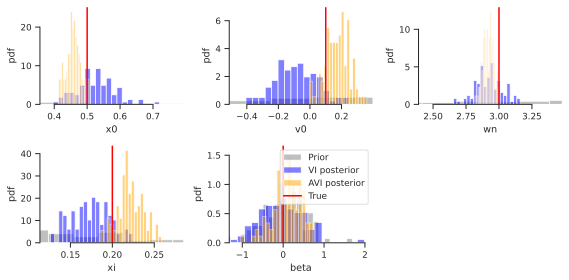

In [37]:
# Visualize posterior distributions
fig, axes = plt.subplots(2, 3, figsize=(8, 4))
axes = axes.flatten()

for i, name in enumerate(list_theta):
    ax = axes[i]

    # Histograms
    ax.hist(prior_samples[:, i], bins=20, alpha=0.5,
            label='Prior', density=True, color='gray')
    ax.hist(vi_samples[:, i], bins=20, alpha=0.5,
            label="VI posterior", density=True, color="blue")
    ax.hist(avi_samples[:, i], bins=20, alpha=0.5,
            label="AVI posterior", density=True, color="orange")

    # True value
    ax.axvline(actual_theta[i], color="red",
              linestyle="-", linewidth=1.5, label="True")

    # Plot range
    min_range = min(vi_samples[:, i].min(), avi_samples[:, i].min()) * 0.9
    max_range = max(vi_samples[:, i].max(), avi_samples[:, i].max()) * 1.1
    ax.set_xlim(min_range, max_range)
    ax.set_xlabel(name)
    ax.set_ylabel('pdf')
    if i == len(list_theta) - 1:
        ax.legend()

fig.delaxes(axes[5])
plt.tight_layout()
for ax in axes:
    sns.despine(ax=ax, trim=True)


And the reconstructed trajectories by the posterior:

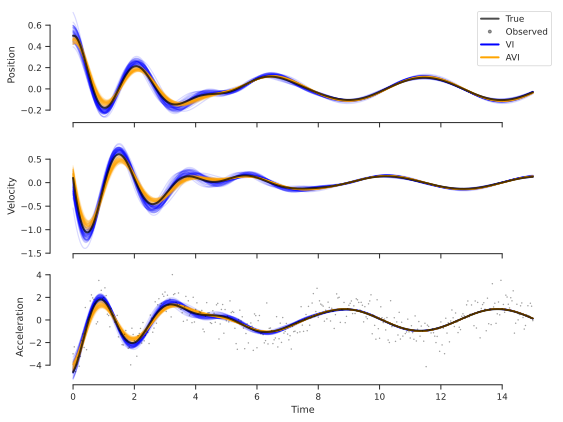

In [38]:
# Compare predicted trajectories using posterior samples (NOT posterior mean)
n_plot = 50  # Samples drawn from posterior
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

# VI samples
for th in vi_samples[:n_plot]:
    xs = solve_ode(th, ts, consts)
    axes[0].plot(ts, xs[:, 0], 'b', alpha=0.15)
    axes[1].plot(ts, xs[:, 1], 'b', alpha=0.15)
    axes[2].plot(ts, observation_duffing(th, xs), 'b', alpha=0.15)

# AVI samples
for th in avi_samples[:n_plot]:
    xs = solve_ode(th, ts, consts)
    axes[0].plot(ts, xs[:, 0], color='orange', alpha=0.15)
    axes[1].plot(ts, xs[:, 1], color='orange', alpha=0.15)
    axes[2].plot(ts, observation_duffing(th, xs), color='orange', alpha=0.15)


# True
axes[0].plot(ts, target_xs[:, 0], 'k-', linewidth=2, label='True', alpha=0.7)
axes[1].plot(ts, target_xs[:, 1], 'k-', linewidth=2, label='True', alpha=0.7)
true_acc = observation_duffing(actual_theta, target_xs)
axes[2].plot(ts, true_acc, 'k-', linewidth=2, label='True', alpha=0.7)
axes[2].plot(ts, target_obs, 'k.', markersize=1, alpha=0.4, label='Observed')

axes[0].set_ylabel('Position')
axes[1].set_ylabel('Velocity')
axes[2].set_ylabel('Acceleration')
axes[2].set_xlabel('Time')

axes[0].plot([], [], 'k.', markersize=6, alpha=0.4, label='Observed')
axes[0].plot([], [], 'b', linewidth=2, label='VI')
axes[0].plot([], [], color='orange', linewidth=2, label='AVI')
axes[0].legend()

plt.tight_layout()
for ax in axes:
    sns.despine(ax=ax, trim=True)


We see that VI is able to reconstruct the trajectory very accurately, while AVI shows a bit more discrepancy. It’s worth keeping in mind that the solution space of AVI is generally a subset of that of VI, and its performance strongly depends on how expressive the chosen inference function is. Feel free to play around with the neural network hyperparameters, number of optimization steps, and signal attributes to see how these choices affect the results.

Also remember that VI optimizes a separate set of variational parameters for each trajectory, which means it has to rerun an optimization every time new data comes in. As a result, inference on new observations can be quite expensive. AVI, on the other hand, shifts most of this cost to the offline training stage. Once trained, inference requires only a single forward pass, making the AVI fast for the inference.